In [8]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, classification_report, RocCurveDisplay
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.inspection import PartialDependenceDisplay
import alibi.explainers
from skopt import BayesSearchCV
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Step 1: Load and preprocess dataset
# Assume dataset is loaded into 'df' DataFrame
# Replace 'your_dataset.csv' with your actual dataset file path
df = pd.read_csv('ds_100K20.csv')

# Separate features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode categorical variables if necessary
X = pd.get_dummies(X, drop_first=True)

# Step 2: Recursive Feature Elimination (RFE) with Random Forest for initial feature selection
rfe_model = RandomForestClassifier(random_state=42)
rfe = RFE(estimator=rfe_model, n_features_to_select=10)  # Select top 10 features as example
rfe.fit(X, y)

# Get selected features
selected_features = X.columns[rfe.support_]
print(f"Selected features using RFE: {selected_features}")

# Reduce the dataset to selected features
X_selected = X[selected_features]

# Convert to NumPy array to avoid shape errors during model fitting
X_selected = X_selected.values

# Split the dataset into training and testing sets using selected features
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

# Step 3: Handle class imbalance using SMOTE on selected features
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Step 4: Define models and hyperparameters for Bayesian Optimization
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False),
    'MLP': MLPClassifier(random_state=42, max_iter=1000),
    'CatBoost': CatBoostClassifier(silent=True, random_state=42)
}

# Define hyperparameter search spaces for each model
search_spaces = {
    'RandomForest': {
        'n_estimators': (50, 200),
        'max_depth': (10, 50),
        'min_samples_split': (2, 10)
    },
    'XGBoost': {
        'n_estimators': (50, 200),
        'learning_rate': (0.01, 0.3, 'log-uniform'),
        'max_depth': (3, 10),
        'gamma': (0, 1)
    },
    'MLP': {
        'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 100)],
        'alpha': (0.0001, 0.01, 'log-uniform')
    },
    'CatBoost': {
        'iterations': (50, 200),
        'depth': (3, 10),
        'learning_rate': (0.01, 0.3, 'log-uniform')
    }
}

# Dictionary to store results
results = {}

# Step 5: Apply Bayesian Optimization and train each model
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    # Initialize Bayesian Optimization with cross-validation
    bayes_cv = BayesSearchCV(estimator=model, search_spaces=search_spaces[model_name], n_iter=10, cv=3, n_jobs=-1, random_state=42, scoring='accuracy')
    bayes_cv.fit(X_train_smote, y_train_smote)
    
    # Get best model and parameters
    best_model = bayes_cv.best_estimator_
    results[model_name] = {
        'best_params': bayes_cv.best_params_,
        'model': best_model
    }
    
    # Evaluate the best model on test set
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else best_model.predict(X_test)  # Handle predict_proba attribute
    results[model_name]['accuracy'] = accuracy_score(y_test, y_pred)
    results[model_name]['roc_auc'] = roc_auc_score(y_test, y_proba) if y_proba.ndim == 1 else roc_auc_score(y_test, y_proba[:, 1])  # Ensure correct dimension
    results[model_name]['f1_score'] = f1_score(y_test, y_pred, average='weighted')
    results[model_name]['confusion_matrix'] = confusion_matrix(y_test, y_pred)
    
    print(f"Best Parameters: {bayes_cv.best_params_}")
    print(f"Accuracy: {results[model_name]['accuracy']:.4f}")
    print(f"ROC-AUC: {results[model_name]['roc_auc']:.4f}")
    print(f"F1 Score: {results[model_name]['f1_score']:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))

# Step 6: Feature Importance Visualization using Bayesian Optimization

# Plot feature importance for Random Forest and XGBoost as examples
for model_name in ['RandomForest', 'XGBoost']:
    if model_name in results:
        # Extract feature importances
        if model_name == 'RandomForest':
            feature_importances = results[model_name]['model'].feature_importances_
        elif model_name == 'XGBoost':
            feature_importances = results[model_name]['model'].feature_importances_

        # Create a DataFrame for feature importances
        feature_importance_df = pd.DataFrame({
            'Feature': selected_features,
            'Importance': feature_importances
        }).sort_values(by='Importance', ascending=False)

        # Plot feature importance
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
        plt.title(f'{model_name} - Feature Importance')
        plt.xlabel('Feature Importance Score')
        plt.ylabel('Features')
        plt.show()

# Step 7: XAI Analysis

# SHAP Analysis (Global Interpretation) for CatBoost
print("\nSHAP Analysis for CatBoost:")
explainer_shap = shap.TreeExplainer(results['CatBoost']['model'])
shap_values = explainer_shap.shap_values(X_test)

# SHAP Summary Plot
shap.summary_plot(shap_values, X_test, feature_names=selected_features)

# PDP Analysis for RandomForest
print("\nPartial Dependence Plot for RandomForest:")
fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(results['RandomForest']['model'], X_test, features=[0, 1], ax=ax)
plt.suptitle("Partial Dependence Plot (PDP) for RandomForest", fontsize=16)
plt.show()

# ALE Analysis for RandomForest
print("\nAccumulated Local Effects (ALE) for RandomForest:")
ale_explainer = alibi.explainers.ALE(results['RandomForest']['model'].predict, feature_names=selected_features)
ale_exp = ale_explainer.explain(X_test)
ale_explainer.plot(ale_exp, features=[0], n_cols=1)
plt.title(f"ALE Plot for feature: {selected_features[0]}")
plt.show()


Selected features using RFE: Index(['url_length', 'n_dots', 'n_hypens', 'n_underline', 'n_slash',
       'n_questionmark', 'n_equal', 'n_and', 'n_percent', 'n_redirection'],
      dtype='object')

Training RandomForest...
Best Parameters: OrderedDict({'max_depth': 26, 'min_samples_split': 8, 'n_estimators': 190})
Accuracy: 0.8867
ROC-AUC: 0.9565
F1 Score: 0.8876
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.89      0.91     12743
           1       0.82      0.89      0.85      7273

    accuracy                           0.89     20016
   macro avg       0.87      0.89      0.88     20016
weighted avg       0.89      0.89      0.89     20016


Training XGBoost...
Best Parameters: OrderedDict({'gamma': 0, 'learning_rate': 0.11883357504897696, 'max_depth': 10, 'n_estimators': 97})
Accuracy: 0.8869
ROC-AUC: 0.9597
F1 Score: 0.8880
Classification Report:
               precision    recall  f1-score   support

           0    

ValueError: can only convert an array of size 1 to a Python scalar

In [12]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, classification_report, RocCurveDisplay
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.inspection import PartialDependenceDisplay
import alibi.explainers
from skopt import BayesSearchCV
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Step 1: Load and preprocess dataset
# Assume dataset is loaded into 'df' DataFrame
# Replace 'your_dataset.csv' with your actual dataset file path
df = pd.read_csv('ds_100K20.csv')

# Separate features (X) and target (y)
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

# Encode categorical variables if necessary
X = pd.get_dummies(X, drop_first=True)

# Ensure that X and y have correct shapes for model input
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

# Step 2: Recursive Feature Elimination (RFE) with Random Forest for initial feature selection
rfe_model = RandomForestClassifier(random_state=42)
rfe = RFE(estimator=rfe_model, n_features_to_select=10)  # Select top 10 features as example
rfe.fit(X, y)

# Get selected features
selected_features = X.columns[rfe.support_]
print(f"Selected features using RFE: {selected_features}")

# Reduce the dataset to selected features
X_selected = X[selected_features]

# Convert to NumPy array to avoid shape errors during model fitting
X_selected = X_selected.values

# Split the dataset into training and testing sets using selected features
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

# Check the shapes of train and test sets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Step 3: Handle class imbalance using SMOTE on selected features
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check the shape after SMOTE to ensure correct input
print(f"Shape of X_train_smote: {X_train_smote.shape}")
print(f"Shape of y_train_smote: {y_train_smote.shape}")

# Step 4: Define models and hyperparameters for Bayesian Optimization
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False),
    'MLP': MLPClassifier(random_state=42, max_iter=1000),
    'CatBoost': CatBoostClassifier(silent=True, random_state=42)
}

# Define hyperparameter search spaces for each model
search_spaces = {
    'RandomForest': {
        'n_estimators': (50, 200),
        'max_depth': (10, 50),
        'min_samples_split': (2, 10)
    },
    'XGBoost': {
        'n_estimators': (50, 200),
        'learning_rate': (0.01, 0.3, 'log-uniform'),
        'max_depth': (3, 10),
        'gamma': (0, 1)
    },
    'MLP': {
        'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 100)],
        'alpha': (0.0001, 0.01, 'log-uniform')
    },
    'CatBoost': {
        'iterations': (50, 200),
        'depth': (3, 10),
        'learning_rate': (0.01, 0.3, 'log-uniform')
    }
}

# Dictionary to store results
results = {}

# Step 5: Apply Bayesian Optimization and train each model
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    # Initialize Bayesian Optimization with cross-validation
    bayes_cv = BayesSearchCV(estimator=model, search_spaces=search_spaces[model_name], n_iter=10, cv=3, n_jobs=-1, random_state=42, scoring='accuracy')
    bayes_cv.fit(X_train_smote, y_train_smote)
    
    # Get best model and parameters
    best_model = bayes_cv.best_estimator_
    results[model_name] = {
        'best_params': bayes_cv.best_params_,
        'model': best_model
    }
    
    # Evaluate the best model on test set
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else best_model.predict(X_test)  # Handle predict_proba attribute
    print(f"Shape of y_pred: {y_pred.shape}")
    print(f"Shape of y_proba: {y_proba.shape if isinstance(y_proba, np.ndarray) else 'N/A'}")
    
    # Ensure y_proba is the correct shape for ROC/AUC calculation
    if len(y_proba.shape) > 1 and y_proba.shape[1] > 1:
        y_proba = y_proba[:, 1]

    results[model_name]['accuracy'] = accuracy_score(y_test, y_pred)
    results[model_name]['roc_auc'] = roc_auc_score(y_test, y_proba)
    results[model_name]['f1_score'] = f1_score(y_test, y_pred, average='weighted')
    results[model_name]['confusion_matrix'] = confusion_matrix(y_test, y_pred)
    
    print(f"Best Parameters: {bayes_cv.best_params_}")
    print(f"Accuracy: {results[model_name]['accuracy']:.4f}")
    print(f"ROC-AUC: {results[model_name]['roc_auc']:.4f}")
    print(f"F1 Score: {results[model_name]['f1_score']:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))

# Step 6: Feature Importance Visualization using Bayesian Optimization

# Plot feature importance for Random Forest and XGBoost as examples
for model_name in ['RandomForest', 'XGBoost']:
    if model_name in results:
        # Extract feature importances
        if model_name == 'RandomForest':
            feature_importances = results[model_name]['model'].feature_importances_
        elif model_name == 'XGBoost':
            feature_importances = results[model_name]['model'].feature_importances_

        # Create a DataFrame for feature importances
        feature_importance_df = pd.DataFrame({
            'Feature': selected_features,
            'Importance': feature_importances
        }).sort_values(by='Importance', ascending=False)

        # Plot feature importance
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
        plt.title(f'{model_name} - Feature Importance')
        plt.xlabel('Feature Importance Score')
        plt.ylabel('Features')
        plt.show()


Shape of X: (100077, 19)
Shape of y: (100077,)
Selected features using RFE: Index(['url_length', 'n_dots', 'n_hypens', 'n_underline', 'n_slash',
       'n_questionmark', 'n_equal', 'n_and', 'n_percent', 'n_redirection'],
      dtype='object')
Shape of X_train: (80061, 10)
Shape of X_test: (20016, 10)
Shape of y_train: (80061,)
Shape of y_test: (20016,)
Shape of X_train_smote: (101944, 10)
Shape of y_train_smote: (101944,)

Training RandomForest...
Shape of y_pred: (20016,)
Shape of y_proba: (20016,)
Best Parameters: OrderedDict({'max_depth': 26, 'min_samples_split': 8, 'n_estimators': 190})
Accuracy: 0.8867
ROC-AUC: 0.9565
F1 Score: 0.8876
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.89      0.91     12743
           1       0.82      0.89      0.85      7273

    accuracy                           0.89     20016
   macro avg       0.87      0.89      0.88     20016
weighted avg       0.89      0.89      0.89     20016




ValueError: can only convert an array of size 1 to a Python scalar


Training RandomForest with Randomized Search...
Best Parameters: {'max_depth': 20, 'min_samples_split': 9, 'n_estimators': 166}
Accuracy: 0.8872
ROC-AUC: 0.9584
F1 Score: 0.8882
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.88      0.91     12743
           1       0.82      0.89      0.85      7273

    accuracy                           0.89     20016
   macro avg       0.87      0.89      0.88     20016
weighted avg       0.89      0.89      0.89     20016


Training XGBoost with Randomized Search...
Best Parameters: {'gamma': 0.056411579027100256, 'learning_rate': 0.22659963168004743, 'max_depth': 8, 'n_estimators': 87}
Accuracy: 0.8870
ROC-AUC: 0.9596
F1 Score: 0.8882
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.88      0.91     12743
           1       0.81      0.90      0.85      7273

    accuracy                           0.89     20016
   macro av

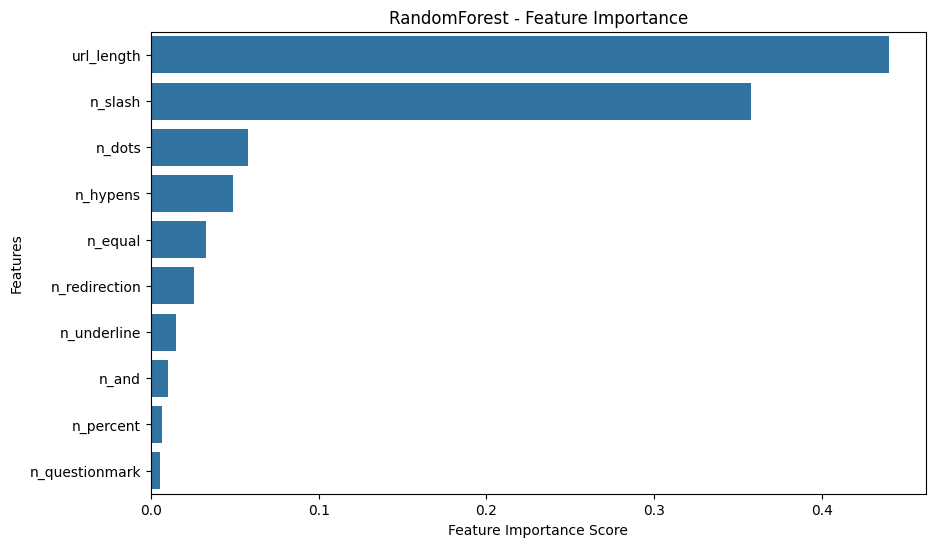

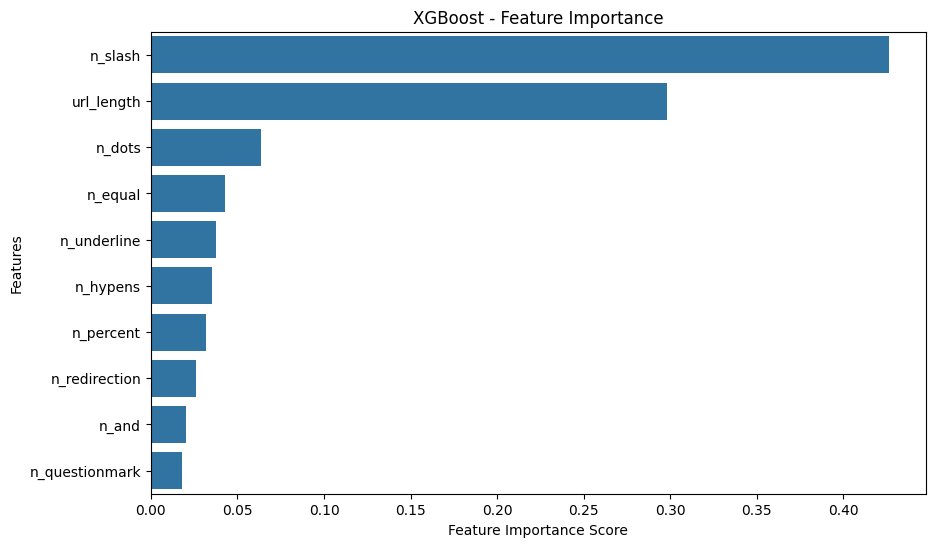


SHAP Analysis for CatBoost:


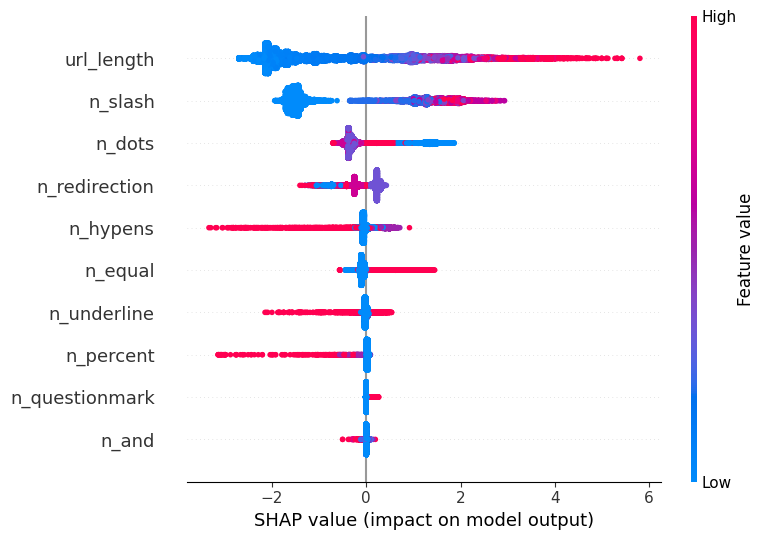


Partial Dependence Plot for RandomForest:


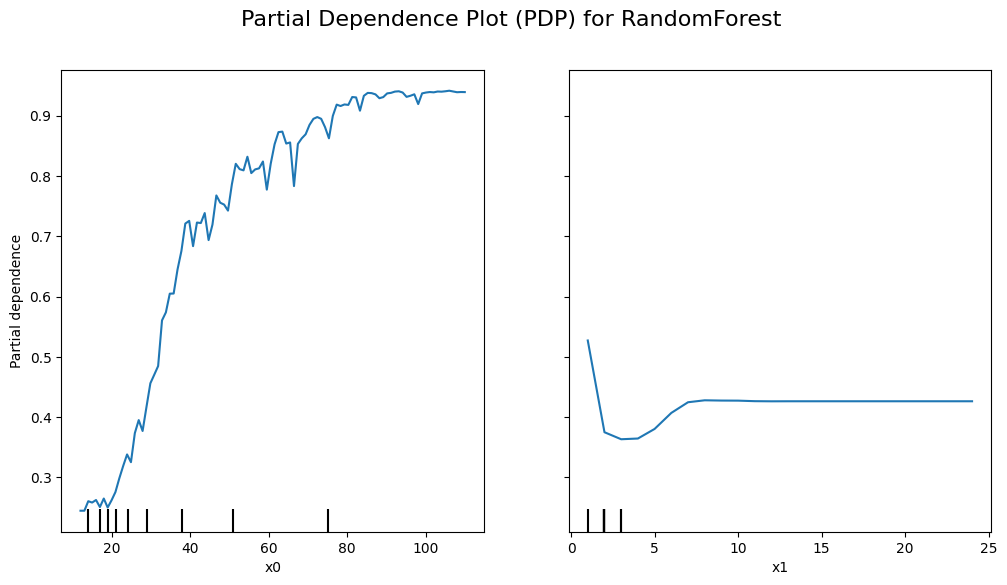


Accumulated Local Effects (ALE) for RandomForest:


AttributeError: 'ALE' object has no attribute 'plot'

In [14]:
# Import necessary libraries for Randomized Search
from sklearn.model_selection import RandomizedSearchCV  # Use RandomizedSearchCV for random search
from scipy.stats import uniform  # For continuous distributions
from scipy.stats import randint  # For discrete distributions

# Step 4: Define models and hyperparameter search spaces for Randomized Search
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False),
    'MLP': MLPClassifier(random_state=42, max_iter=1000),
    'CatBoost': CatBoostClassifier(silent=True, random_state=42)
}

# Adjust hyperparameter search spaces for RandomizedSearchCV using scipy.stats distributions
search_spaces = {
    'RandomForest': {
        'n_estimators': randint(50, 200),             # Use randint for integer values
        'max_depth': randint(10, 50),                 # Use randint for integer values
        'min_samples_split': randint(2, 10)           # Use randint for integer values
    },
    'XGBoost': {
        'n_estimators': randint(50, 200),             # Use randint for integer values
        'learning_rate': uniform(0.01, 0.3),          # Use uniform for continuous values
        'max_depth': randint(3, 10),                  # Use randint for integer values
        'gamma': uniform(0, 1)                        # Use uniform for continuous values
    },
    'MLP': {
        'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 100)],  # List for discrete choices
        'alpha': uniform(0.0001, 0.01)                                # Use uniform for continuous values
    },
    'CatBoost': {
        'iterations': randint(50, 200),               # Use randint for integer values
        'depth': randint(3, 10),                      # Use randint for integer values
        'learning_rate': uniform(0.01, 0.3)           # Use uniform for continuous values
    }
}

# Dictionary to store results
results = {}

# Step 5: Apply Randomized Search and train each model
for model_name, model in models.items():
    print(f"\nTraining {model_name} with Randomized Search...")
    
    # Initialize RandomizedSearchCV with cross-validation
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=search_spaces[model_name],
        n_iter=10,  # Number of random iterations
        cv=3,       # 3-fold cross-validation
        n_jobs=-1,  # Use all available cores
        random_state=42,
        scoring='accuracy'
    )
    
    # Fit the random search to the data
    random_search.fit(X_train_smote, y_train_smote)
    
    # Get best model and parameters
    best_model = random_search.best_estimator_
    results[model_name] = {
        'best_params': random_search.best_params_,
        'model': best_model
    }
    
    # Evaluate the best model on test set
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else best_model.predict(X_test)  # Handle predict_proba attribute
    results[model_name]['accuracy'] = accuracy_score(y_test, y_pred)
    results[model_name]['roc_auc'] = roc_auc_score(y_test, y_proba)
    results[model_name]['f1_score'] = f1_score(y_test, y_pred, average='weighted')
    results[model_name]['confusion_matrix'] = confusion_matrix(y_test, y_pred)
    
    print(f"Best Parameters: {random_search.best_params_}")
    print(f"Accuracy: {results[model_name]['accuracy']:.4f}")
    print(f"ROC-AUC: {results[model_name]['roc_auc']:.4f}")
    print(f"F1 Score: {results[model_name]['f1_score']:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))

# Step 6: Feature Importance Visualization using Randomized Search Results

# Plot feature importance for Random Forest and XGBoost as examples
for model_name in ['RandomForest', 'XGBoost']:
    if model_name in results:
        # Extract feature importances
        if model_name == 'RandomForest':
            feature_importances = results[model_name]['model'].feature_importances_
        elif model_name == 'XGBoost':
            feature_importances = results[model_name]['model'].feature_importances_

        # Create a DataFrame for feature importances
        feature_importance_df = pd.DataFrame({
            'Feature': selected_features,
            'Importance': feature_importances
        }).sort_values(by='Importance', ascending=False)

        # Plot feature importance
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
        plt.title(f'{model_name} - Feature Importance')
        plt.xlabel('Feature Importance Score')
        plt.ylabel('Features')
        plt.show()

# Step 7: XAI Analysis

# SHAP Analysis (Global Interpretation) for CatBoost
print("\nSHAP Analysis for CatBoost:")
explainer_shap = shap.TreeExplainer(results['CatBoost']['model'])
shap_values = explainer_shap.shap_values(X_test)

# SHAP Summary Plot
shap.summary_plot(shap_values, X_test, feature_names=selected_features)

# PDP Analysis for RandomForest
print("\nPartial Dependence Plot for RandomForest:")
fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(results['RandomForest']['model'], X_test, features=[0, 1], ax=ax)
plt.suptitle("Partial Dependence Plot (PDP) for RandomForest", fontsize=16)
plt.show()

# ALE Analysis for RandomForest
print("\nAccumulated Local Effects (ALE) for RandomForest:")
ale_explainer = alibi.explainers.ALE(results['RandomForest']['model'].predict, feature_names=selected_features)
ale_exp = ale_explainer.explain(X_test)
ale_explainer.plot(ale_exp, features=[0], n_cols=1)
plt.title(f"ALE Plot for feature: {selected_features[0]}")
plt.show()
